# Evolutionary Algorithm for the Traveling Salesman Problem using an Indirect Approach

The goal is to find a short route that visits every city exactly once and then returns to the starting city.

In this exercise I use an indirect approach. This means that the evolutionary algorithm does not store the tour directly. Instead, it stores an integer genotype based on the Grefenstette decoder, and then a decoder function converts that genotype into a valid TSP tour.

This is useful because normal crossover and mutation can be applied to the genotype, while the decoder guarantees that the final tour is feasible.



## 1. Problem definition

Suppose we have $n$ cities.

Each city $i$ has coordinates:

$$
(x_i, y_i)
$$

A solution to the TSP is a tour:

$$
	ext{tour} = [c_1, c_2, ..., c_n]
$$

where each city appears exactly once.

The total tour distance is:

$$
D(	ext{tour}) = d(c_1,c_2) + d(c_2,c_3) + ... + d(c_n,c_1)
$$

The last term $d(c_n,c_1)$ means that the salesman returns to the starting city.

The distance between two cities $a$ and $b$ is the Euclidean distance:

$$
d(a,b) = \sqrt{(x_a-x_b)^2 + (y_a-y_b)^2}
$$

Because the TSP is a minimization problem, the objective is:

$$
\min D(	ext{tour})
$$

However, many evolutionary algorithms are written as maximization algorithms. So I define fitness as:

$$
\text{fitness} = -D(	ext{tour})
$$

This way, a shorter tour has a larger fitness value.


## 2. Direct vs indirect approach

A direct approach would store the tour directly as a permutation.

Example:

```text
[3, 0, 4, 1, 2]
```

This means: visit city 3, then city 0, then city 4, then city 1, then city 2.

The problem with a direct approach is that normal crossover can create invalid tours.

Example:

```text
Parent 1 = [0, 1, 2, 3, 4]
Parent 2 = [4, 3, 2, 1, 0]
```

A normal one-point crossover might create:

```text
Child = [0, 1, 2, 1, 0]
```

This is invalid because some cities are repeated and some cities are missing.

In this notebook I use an indirect approach:

```text
genotype  ->  decoder  ->  phenotype
Grefenstette genotype -> TSP tour -> distance
```

The EA modifies the genotype. The decoder converts the genotype into a valid tour.


## 3. Indirect representation: Grefenstette decoder

The genotype is an integer vector:

$$
a = [a_1, a_2, ..., a_n]
$$

Each gene has a different allowed range:

$$
a_i \in \{1,2,...,n+1-i\}
$$

This means that the first gene can select from all cities, the second gene can select from the remaining cities, and so on.

For example, if $n=5$, the valid ranges are:

```text
gene 1: 1 to 5
gene 2: 1 to 4
gene 3: 1 to 3
gene 4: 1 to 2
gene 5: 1 to 1
```

So one valid genotype is:

```text
[4, 2, 3, 1, 1]
```

### Decoder idea

Start with an ordered list of available cities:

```text
[A, B, C, D, E]
```

The first gene is 4, so we choose the 4th available city:

```text
D
```

Then we remove D from the list:

```text
[A, B, C, E]
```

The second gene is 2, so we choose the 2nd available city:

```text
B
```

Continue the same process until all cities are selected.

The example becomes:

```text
[4, 2, 3, 1, 1]  ->  D B E A C
```

The important point is that the genotype is not the tour directly. The genotype only tells the decoder how to construct the tour.



## 4. Evolutionary Algorithm design

### Representation
The genotype is an integer vector using the Grefenstette representation.

The phenotype is the actual TSP tour obtained after decoding.

### Fitness function
The fitness is:

$$
	ext{fitness} = -D(	ext{decode}(a))
$$

where $a$ is the genotype.

The original TSP objective is to minimize distance. However, evolutionary algorithms are often written as maximization algorithms. For that reason, I use negative distance as fitness.

### Parent selection
I use binary tournament selection.

This means:

1. Randomly choose two individuals.
2. Compare their fitness values.
3. Select the one with better fitness.

I use this because it is simple, does not need probability normalization, and works well for many EAs.

### Crossover
I use one-point crossover.

This operator cuts two parent genotypes at one position and exchanges the right-hand parts.

It is appropriate here because the Grefenstette genotype has fixed positions, and every position has its own valid range. Since crossover copies gene values from the same positions, the children remain valid genotypes.

### Mutation
I use random-reset mutation.

For each gene, with probability $1/n$, the gene is replaced by another random value from its valid range.

This is appropriate because each gene has a different valid range.

### Survivor selection
I use elitism.

This means the best individual from the current generation is copied into the next generation. This prevents losing the best solution found so far.



## 5. Pseudocode

```text
Input:
    city coordinates
    population_size
    max_evaluations
    crossover_probability
    mutation_probability

Create an initial population of random Grefenstette genotypes
Decode each genotype into a TSP tour
Evaluate each tour using fitness = -tour_distance

while number_of_evaluations < max_evaluations:

    Create a new empty population

    Copy the best current individual into the new population  # elitism

    while the new population is not full:

        Select parent 1 using binary tournament selection
        Select parent 2 using binary tournament selection

        Apply one-point crossover with probability pc

        Apply random-reset mutation with probability pm

        Add the children to the new population

    Replace old population with new population
    Decode and evaluate the new population

Return the best tour found
```




## 6. Why these choices?

1.- **TSP** because it is a classical combinatorial optimization problem.

2.- **Indirect representation** because the genotype is not the tour itself. The EA evolves an integer vector, and the decoder converts it into a feasible tour.

3.- **Grefenstette decoder** because it is an example of a decoder function for the TSP.

4.- **Decoder function** because it guarantees that every generated genotype becomes a valid TSP tour.

5.- **Binary tournament selection** because it is easy to implement and works by comparing fitness values directly.

6.- **One-point crossover** because it is simple and, in this representation, it preserves validity because each child receives gene values from the same positions as the parents.

7.- **Random-reset mutation** because each gene has a specific valid range, so mutation must choose a new value inside that range.

8.- **Elitism** because it keeps the best solution found so far from being lost.



## 7. Python implementation


In [1]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def create_distance_matrix(cities):
    """Create the TSPLIB EUC_2D integer distance matrix."""
    differences = cities[:, np.newaxis, :] - cities[np.newaxis, :, :]
    euclidean_distances = np.sqrt(np.sum(differences**2, axis=2))
    return np.floor(euclidean_distances + 0.5).astype(int)


def tour_distance(tour, distance_matrix):
    """Calculate the total distance of a closed TSP tour."""
    total = 0
    n = len(tour)

    for i in range(n):
        current_city = tour[i]
        next_city = tour[(i + 1) % n]
        total += distance_matrix[current_city, next_city]

    return int(total)


In [3]:
def random_grefenstette_genotype(n_cities):
    """Create one random valid Grefenstette genotype.

    For position i using zero-based Python indexing, the valid values are:
    1, 2, ..., n_cities - i
    """
    genotype = []

    for i in range(n_cities):
        max_value = n_cities - i
        genotype.append(np.random.randint(1, max_value + 1))

    return np.array(genotype, dtype=int)


def decode_grefenstette_genotype(genotype):
    """Decode a Grefenstette genotype into a valid TSP tour.

    Each gene selects one city from the current list of available cities.
    After selecting a city, that city is removed from the list.
    """
    n = len(genotype)
    available_cities = list(range(n))
    tour = []

    for gene in genotype:
        # The genotype is 1-based, but Python lists are 0-based.
        selected_index = int(gene) - 1
        selected_city = available_cities.pop(selected_index)
        tour.append(selected_city)

    return np.array(tour, dtype=int)


def initialize_population(population_size, n_cities):
    """Create the initial population of random Grefenstette genotypes."""
    population = []

    for _ in range(population_size):
        individual = random_grefenstette_genotype(n_cities)
        population.append(individual)

    return np.array(population)



In [4]:
def evaluate_individual(genotype, distance_matrix):
    """Decode the genotype and calculate its fitness."""
    tour = decode_grefenstette_genotype(genotype)
    distance = tour_distance(tour, distance_matrix)
    fitness = -distance
    return fitness


def evaluate_population(population, distance_matrix):
    """Evaluate all individuals in the population."""
    fitness_values = []

    for individual in population:
        fitness = evaluate_individual(individual, distance_matrix)
        fitness_values.append(fitness)

    return np.array(fitness_values)



In [5]:
def tournament_selection(population, fitness_values, tournament_size=2):
    """Select one parent using tournament selection."""
    candidate_indices = np.random.choice(len(population), size=tournament_size, replace=False)
    best_index = candidate_indices[np.argmax(fitness_values[candidate_indices])]
    return population[best_index].copy()


def one_point_crossover(parent1, parent2, crossover_probability):
    """Apply one-point crossover to two Grefenstette-genotype parents."""
    n = len(parent1)

    if np.random.rand() > crossover_probability or n < 2:
        return parent1.copy(), parent2.copy()

    crossover_point = np.random.randint(1, n)

    child1 = np.concatenate([parent1[:crossover_point], parent2[crossover_point:]])
    child2 = np.concatenate([parent2[:crossover_point], parent1[crossover_point:]])

    return child1, child2


def random_reset_mutation(individual, mutation_probability):
    """Mutate a Grefenstette genotype by resetting genes to valid random values."""
    mutant = individual.copy()
    n = len(mutant)

    for i in range(n):
        if np.random.rand() < mutation_probability:
            max_value = n - i
            mutant[i] = np.random.randint(1, max_value + 1)

    return mutant



In [6]:
def evolutionary_algorithm_tsp(
    cities,
    population_size=50,
    max_evaluations=3000,
    crossover_probability=0.9,
    mutation_probability=None,
    tournament_size=2,
    random_seed=None
):
    """Run an evolutionary algorithm for the TSP using an indirect representation."""

    if random_seed is not None:
        np.random.seed(random_seed)
        random.seed(random_seed)

    n_cities = len(cities)

    if mutation_probability is None:
        mutation_probability = 1 / n_cities

    distance_matrix = create_distance_matrix(cities)

    start_time = time.time()

    population = initialize_population(population_size, n_cities)
    fitness_values = evaluate_population(population, distance_matrix)
    evaluations = population_size

    best_fitness_history = []
    average_fitness_history = []

    while evaluations < max_evaluations:
        new_population = []

        # Elitism: copy the best individual to the next generation.
        best_index = np.argmax(fitness_values)
        elite = population[best_index].copy()
        new_population.append(elite)

        while len(new_population) < population_size and evaluations < max_evaluations:
            parent1 = tournament_selection(population, fitness_values, tournament_size)
            parent2 = tournament_selection(population, fitness_values, tournament_size)

            child1, child2 = one_point_crossover(parent1, parent2, crossover_probability)

            child1 = random_reset_mutation(child1, mutation_probability)
            child2 = random_reset_mutation(child2, mutation_probability)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = np.array(new_population)
        fitness_values = evaluate_population(population, distance_matrix)
        evaluations += len(population)

        best_fitness_history.append(np.max(fitness_values))
        average_fitness_history.append(np.mean(fitness_values))

    end_time = time.time()
    running_time = end_time - start_time

    best_index = np.argmax(fitness_values)
    best_genotype = population[best_index]
    best_tour = decode_grefenstette_genotype(best_genotype)
    best_fitness = fitness_values[best_index]
    best_distance = -best_fitness
    average_fitness = np.mean(fitness_values)
    average_distance = -average_fitness

    return {
        "best_genotype": best_genotype,
        "best_tour": best_tour,
        "best_fitness": best_fitness,
        "best_distance": best_distance,
        "average_fitness": average_fitness,
        "average_distance": average_distance,
        "running_time": running_time,
        "best_fitness_history": best_fitness_history,
        "average_fitness_history": average_fitness_history
    }



## 8. TSPLIB95 benchmark instances

Three official symmetric TSP instances from TSPLIB95:

1. `berlin52`: 52 cities, known optimum 7542.
2. `st70`: 70 cities, known optimum 675.
3. `eil101`: 101 cities, known optimum 629.

Source: <https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/>

All three use `EDGE_WEIGHT_TYPE: EUC_2D`. According to the TSPLIB95
specification, their Euclidean distances must be rounded to the nearest integer.
This differs from using raw floating-point Euclidean distance and is necessary
for a valid comparison with the published optimum.


In [7]:
from pathlib import Path
import gzip
import io
import urllib.request

DATA_DIR = Path("tsplib95")
DATA_DIR.mkdir(exist_ok=True)

INSTANCE_INFO = {
    "berlin52": {
        "url": "https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/berlin52.tsp.gz",
        "optimum": 7542,
    },
    "st70": {
        "url": "https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/st70.tsp.gz",
        "optimum": 675,
    },
    "eil101": {
        "url": "https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil101.tsp.gz",
        "optimum": 629,
    },
}


def download_if_missing(name, url):
    path = DATA_DIR / f"{name}.tsp"
    if not path.exists():
        print(f"Downloading {name} from TSPLIB95...")
        with urllib.request.urlopen(url) as response:
            content = gzip.decompress(response.read()).decode("utf-8")
        path.write_text(content, encoding="utf-8")
    return path


def load_tsplib_euc_2d(path):
    """Load a NODE_COORD_SECTION instance with EDGE_WEIGHT_TYPE EUC_2D."""
    metadata = {}
    coordinates = []
    reading_coordinates = False

    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if line == "NODE_COORD_SECTION":
            reading_coordinates = True
            continue
        if line == "EOF":
            break
        if reading_coordinates:
            parts = line.split()
            coordinates.append((float(parts[1]), float(parts[2])))
        elif ":" in line:
            key, value = line.split(":", 1)
            metadata[key.strip()] = value.strip()

    if metadata.get("TYPE") != "TSP":
        raise ValueError(f"{path.name}: expected TYPE TSP")
    if metadata.get("EDGE_WEIGHT_TYPE") != "EUC_2D":
        raise ValueError(f"{path.name}: only EUC_2D is supported")
    if len(coordinates) != int(metadata["DIMENSION"]):
        raise ValueError(f"{path.name}: coordinate count does not match DIMENSION")

    return np.asarray(coordinates, dtype=float), metadata


instances = {}
for name, info in INSTANCE_INFO.items():
    path = download_if_missing(name, info["url"])
    cities, metadata = load_tsplib_euc_2d(path)
    instances[name] = {
        "cities": cities,
        "optimum": info["optimum"],
        "metadata": metadata,
    }

instance_overview = pd.DataFrame([
    {
        "instance": name,
        "cities": len(data["cities"]),
        "edge_weight_type": data["metadata"]["EDGE_WEIGHT_TYPE"],
        "known_optimum": data["optimum"],
    }
    for name, data in instances.items()
])
instance_overview


,instance,cities,edge_weight_type,known_optimum
0,berlin52,52,EUC_2D,7542
1,st70,70,EUC_2D,675
2,eil101,101,EUC_2D,629


## 9. Experimental setup

The evolutionary algorithm is stochastic, so each instance is evaluated in 10
independent runs. Every run uses exactly the same evaluation budget.

| Parameter | Value |
|---|---:|
| Population size | 100 |
| Maximum evaluations | 5,000 |
| Crossover probability | 0.9 |
| Mutation probability | $1/n$ |
| Tournament size | 2 |
| Runs per instance | 10 |
| Elitism | Yes |

The published optimum is used only to evaluate the results; it is not supplied
to the evolutionary algorithm.


In [8]:
POPULATION_SIZE = 100
MAX_EVALUATIONS = 5000
CROSSOVER_PROBABILITY = 0.9
TOURNAMENT_SIZE = 2
N_RUNS = 10

experiment_results = []
histories = {}
best_result_by_instance = {}

for instance_name, instance_data in instances.items():
    cities = instance_data["cities"]
    known_optimum = instance_data["optimum"]
    mutation_probability = 1 / len(cities)
    histories[instance_name] = []

    for run in range(N_RUNS):
        result = evolutionary_algorithm_tsp(
            cities=cities,
            population_size=POPULATION_SIZE,
            max_evaluations=MAX_EVALUATIONS,
            crossover_probability=CROSSOVER_PROBABILITY,
            mutation_probability=mutation_probability,
            tournament_size=TOURNAMENT_SIZE,
            random_seed=1000 + run,
        )
        gap = result["best_distance"] - known_optimum
        experiment_results.append({
            "Instance": instance_name,
            "Run": run + 1,
            "Best fitness": result["best_fitness"],
            "Average population fitness": result["average_fitness"],
            "Best distance": result["best_distance"],
            "Average population distance": result["average_distance"],
            "Known optimum": known_optimum,
            "Absolute gap": gap,
            "Relative gap (%)": 100 * gap / known_optimum,
            "Time (s)": result["running_time"],
        })
        histories[instance_name].append(result)

        previous = best_result_by_instance.get(instance_name)
        if previous is None or result["best_distance"] < previous["best_distance"]:
            best_result_by_instance[instance_name] = result

results_df = pd.DataFrame(experiment_results)
results_df.head(10)


,Instance,Run,Best fitness,Average population fitness,Best distance,Average population distance,Known optimum,Absolute gap,Relative gap (%),Time (s)
0,berlin52,1,-19101,-23191.08,19101,23191.08,7542,11559,153.261734,0.327761
1,berlin52,2,-19228,-23871.67,19228,23871.67,7542,11686,154.945638,0.314136
2,berlin52,3,-18165,-21992.20,18165,21992.20,7542,10623,140.851233,0.323957
3,berlin52,4,-20500,-24441.09,20500,24441.09,7542,12958,171.811191,0.318557
4,berlin52,5,-22097,-26056.08,22097,26056.08,7542,14555,192.985945,0.306728
5,berlin52,6,-19025,-23368.89,19025,23368.89,7542,11483,152.254044,0.306825
6,berlin52,7,-18544,-22123.82,18544,22123.82,7542,11002,145.876425,0.304912
7,berlin52,8,-17867,-23542.48,17867,23542.48,7542,10325,136.900027,0.306392
8,berlin52,9,-19150,-23680.28,19150,23680.28,7542,11608,153.911429,0.308072
9,berlin52,10,-18493,-23764.65,18493,23764.65,7542,10951,145.200212,0.305607


## 10. Summary results

Because fitness is the negative tour distance, a larger fitness is better while
a smaller distance is better. The table explicitly compares the best fitness,
average population fitness, average time, and gap from the known optimum under
the fixed evaluation budget.


In [9]:
summary_df = (
    results_df.groupby("Instance")
    .agg(
        cities=("Instance", "size"),
        known_optimum=("Known optimum", "first"),
        best_distance_found=("Best distance", "min"),
        average_best_distance=("Best distance", "mean"),
        average_population_distance=("Average population distance", "mean"),
        average_best_fitness=("Best fitness", "mean"),
        average_population_fitness=("Average population fitness", "mean"),
        average_relative_gap_percent=("Relative gap (%)", "mean"),
        average_time_seconds=("Time (s)", "mean"),
    )
    .reset_index()
)
summary_df["cities"] = summary_df["Instance"].map(
    lambda name: len(instances[name]["cities"])
)
summary_df.round(3)


,Instance,cities,known_optimum,best_distance_found,average_best_distance,average_population_distance,average_best_fitness,average_population_fitness,average_relative_gap_percent,average_time_seconds
0,berlin52,52,7542,17867,19217.0,23603.224,-19217.0,-23603.224,154.800,0.312
1,eil101,101,629,2437,2529.2,2886.514,-2529.2,-2886.514,302.099,0.531
2,st70,70,675,2396,2604.0,3137.779,-2604.0,-3137.779,285.778,0.392


## 11. Best fitness and average population fitness

The curves below average the 10 runs for each instance. Since fitness values
are negative, curves closer to zero represent shorter tours and therefore
better solutions. The best-fitness curve describes the strongest individual;
the population-average curve describes the quality of the population as a
whole.


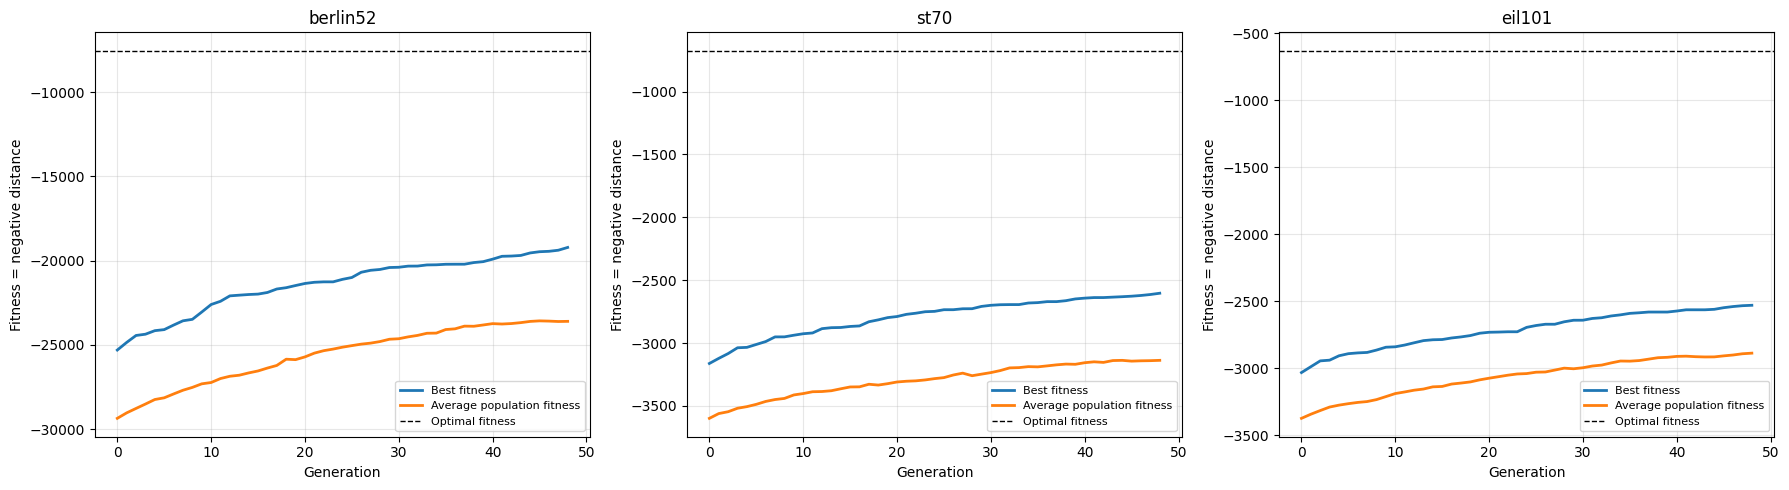

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (instance_name, runs) in zip(axes, histories.items()):
    best_curves = [run["best_fitness_history"] for run in runs]
    average_curves = [run["average_fitness_history"] for run in runs]
    min_len = min(
        min(map(len, best_curves)),
        min(map(len, average_curves)),
    )
    mean_best = np.mean([curve[:min_len] for curve in best_curves], axis=0)
    mean_average = np.mean([curve[:min_len] for curve in average_curves], axis=0)

    ax.plot(mean_best, label="Best fitness", linewidth=2)
    ax.plot(mean_average, label="Average population fitness", linewidth=2)
    ax.axhline(
        -instances[instance_name]["optimum"],
        color="black",
        linestyle="--",
        linewidth=1,
        label="Optimal fitness",
    )
    ax.set_title(instance_name)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness = negative distance")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 12. Distance and running-time comparisons

These charts present the same experiment in the original minimization scale:
smaller tour distances and smaller gaps are better.


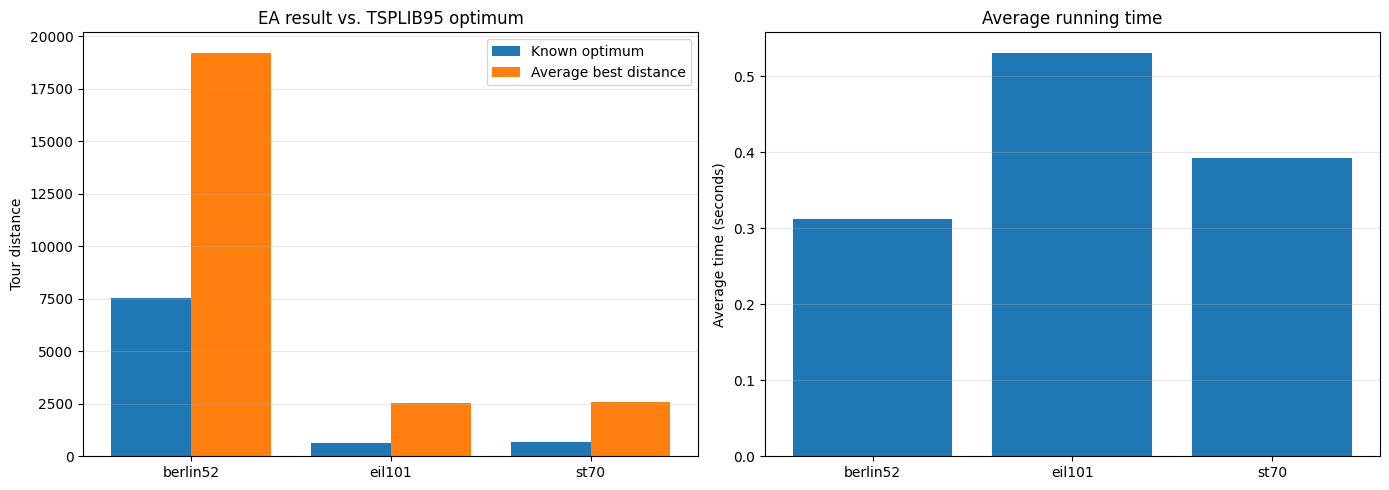

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(summary_df))

axes[0].bar(x - 0.2, summary_df["known_optimum"], 0.4, label="Known optimum")
axes[0].bar(
    x + 0.2,
    summary_df["average_best_distance"],
    0.4,
    label="Average best distance",
)
axes[0].set_xticks(x, summary_df["Instance"])
axes[0].set_ylabel("Tour distance")
axes[0].set_title("EA result vs. TSPLIB95 optimum")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(summary_df["Instance"], summary_df["average_time_seconds"])
axes[1].set_ylabel("Average time (seconds)")
axes[1].set_title("Average running time")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Best tour found for each TSPLIB95 instance

Each phenotype shown below is produced by decoding a Grefenstette genotype.
The decoder guarantees that every city appears exactly once.


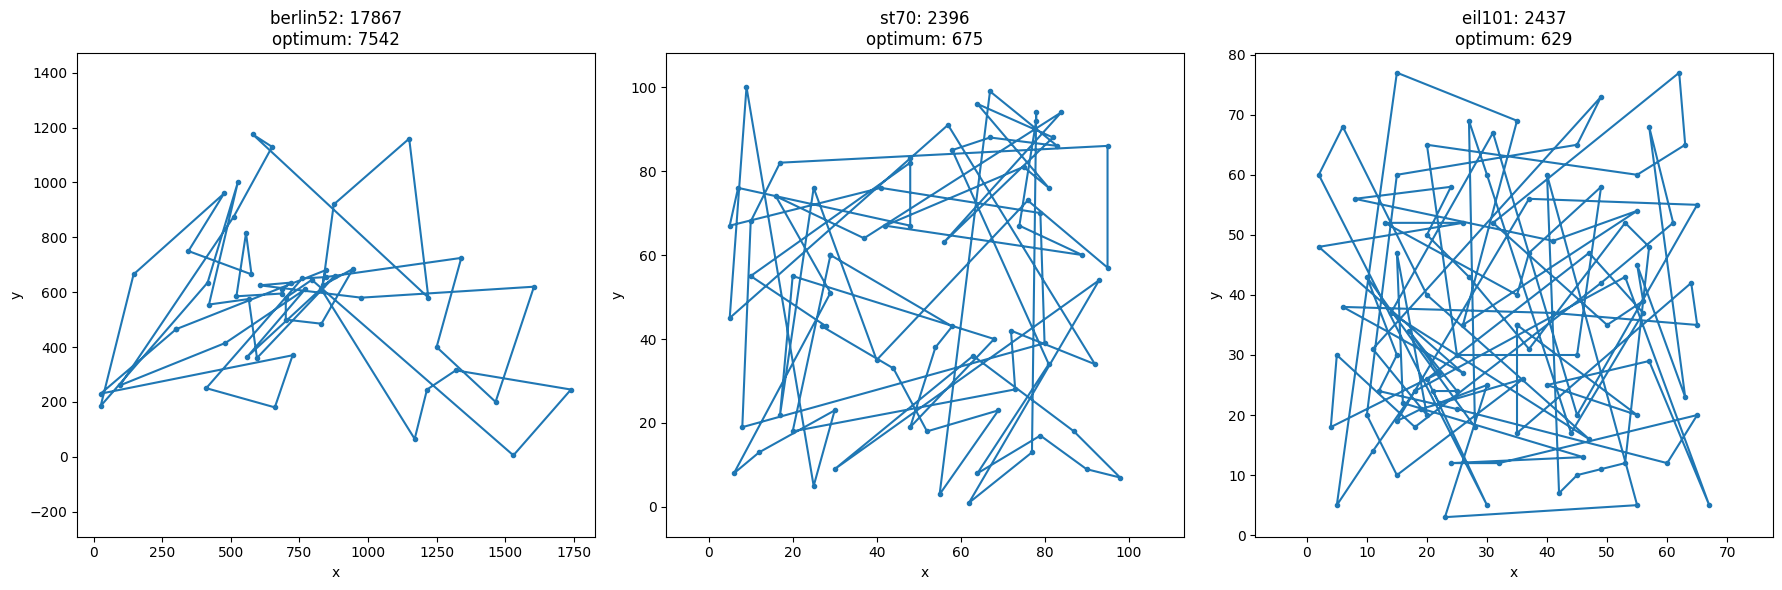

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (instance_name, instance_data) in zip(axes, instances.items()):
    cities = instance_data["cities"]
    result = best_result_by_instance[instance_name]
    ordered_cities = cities[result["best_tour"]]
    closed_tour = np.vstack([ordered_cities, ordered_cities[0]])

    ax.plot(closed_tour[:, 0], closed_tour[:, 1], marker="o", markersize=3)
    ax.set_title(
        f"{instance_name}: {result['best_distance']:.0f}\n"
        f"optimum: {instance_data['optimum']}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()


## 14. Final interpretation

The experiment confirms that the Grefenstette representation is an indirect
approach: the evolutionary algorithm modifies an integer genotype and a
decoder maps it to a valid TSP tour. Feasibility is guaranteed because each
gene selects one city from the list of cities that remain available.

The fixed evaluation budget makes the comparison across the three benchmark
instances consistent. Best fitness shows the quality of the strongest
individual, average population fitness shows the behavior of the entire
population, and average running time describes the computational cost.
